# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Telco Customer Churn

---

## Business Context
You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and must produce a production-ready recommendation. There is no prescribed model — you must decide and defend the decision with evidence.

**Dataset:** Telco Customer Churn — 7,043 rows · 21 columns · Target: `Churn` (Yes/No)

---

This notebook addresses the 5 tasks in order:
1. Understand the Problem
2. Classification Experiment
3. Regression Experiment
4. Evaluation Integrity
5. Production Decision


In [1]:
# Core imports — keep everything reproducible
import warnings
warnings.filterwarnings('ignore')
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 90

# sklearn
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (LogisticRegression, RidgeClassifier,
                                  SGDClassifier, LinearRegression,
                                  Ridge, Lasso, ElasticNet, lasso_path)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             log_loss, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve,
                             mean_absolute_error, mean_squared_error, r2_score)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Setup complete · sklearn version:', __import__('sklearn').__version__)

Setup complete · sklearn version: 1.7.2


---
# Task 1 — Understand the Problem First

Before any modelling, formulate the problem, profile the data, build a naive baseline.

## 1.1 Load & Inspect

In [2]:
# Load the raw CSV. Each row = one customer.
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Inspect dtypes — note TotalCharges is object, not float
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Summary statistics for numeric columns
df.describe(include='all').T.head(15)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations from inspection:**

- Each row = one customer, 7043 customers, 21 columns
- `TotalCharges` is dtype `object` — suspicious for what should be a numeric column
- `SeniorCitizen` is encoded as 0/1 (integer); other binary columns are Yes/No strings
- `tenure` ranges 0–72 months. A tenure of 0 likely means the customer just signed up
- The remaining categorical columns are service / contract attributes — all need encoding

---
## 1.2 Problem Formulation

**Formal ML problem:**

- **X (feature space):** All columns except `customerID` and `Churn`. Mix of:
  - Numeric: `tenure`, `MonthlyCharges`, `TotalCharges`, `SeniorCitizen`
  - Categorical: `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`
- **y (target):** `Churn ∈ {0, 1}` — did the customer leave in the observation window?
- **Distribution of y:** Bernoulli (binary outcome). The natural likelihood is `p^y · (1-p)^(1-y)`.
- **Natural loss function:** Binary cross-entropy (a.k.a. log loss). This is the negative log-likelihood of the Bernoulli model.
- **Hypothesis class H:** Linear models — `f_θ(x) = σ(w·x + b)` for classification, `f_θ(x) = w·x + b` for regression. We search over weight vectors `w`.

**Three assumptions (and what breaks if violated):**

1. **Linearity in the log-odds.** We assume `log(p/(1-p)) = w·x + b`. If churn depends on non-linear interactions (e.g., "month-to-month AND high charges AND short tenure"), a linear model will underfit and miss those customers.
2. **IID samples (independent customers from a single distribution).** If samples are not IID — e.g., several family members share a plan, or customers were sampled non-uniformly across regions — the estimated standard errors and probabilities will be wrong, and the model will be biased toward the over-represented segment.
3. **Stationarity (no distribution shift between train and deploy).** If churn drivers shift over time (a new competitor launches, prices change, COVID lockdown), the model's coefficients become stale and performance degrades silently.

**Sources of uncertainty in this dataset:**

- `TotalCharges` has whitespace strings — missing data, not random (correlates with `tenure == 0`)
- Class imbalance — ~27% churn, so accuracy is misleading
- Label definition — "Churn" within what window? Voluntary vs involuntary?
- No timestamps — we cannot do temporal validation, so distribution shift is invisible
- No region/segment label — sampling bias is unverifiable
- `tenure == 0` rows — new customers; the data-generating process here is different from established customers

---
## 1.3 Data Profiling & Fixing

In [5]:
# TotalCharges contains whitespace strings where customers have tenure==0 (no bill yet)
# Use to_numeric with errors='coerce' to turn ' ' into NaN
mask_blank = df['TotalCharges'].astype(str).str.strip() == ''
print('Whitespace TotalCharges rows:', mask_blank.sum())
print('Their tenure values:', df.loc[mask_blank, 'tenure'].unique())

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# These are all tenure==0 customers — TotalCharges = 0 is the correct imputation, not the mean
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print('Remaining NaN in TotalCharges:', df['TotalCharges'].isna().sum())

Whitespace TotalCharges rows: 11
Their tenure values: [0]
Remaining NaN in TotalCharges: 0


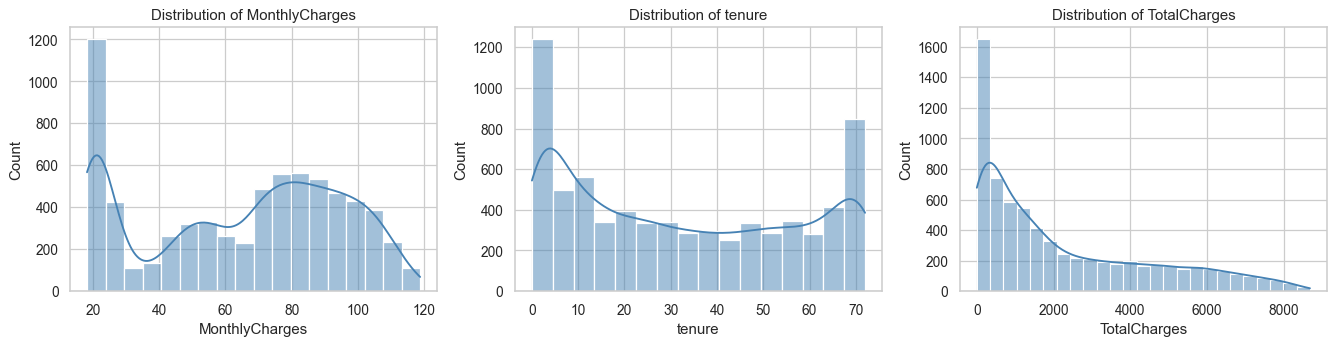

In [6]:
# Plot distributions of the three numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['MonthlyCharges', 'tenure', 'TotalCharges']):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

# Distribution shapes:
# - MonthlyCharges: bimodal — a spike near $20 (basic phone only) and a broad hump $70–$110
# - tenure: U-shaped — many new customers (tenure 1-2) and many long-term (~70+)
# - TotalCharges: heavily right-skewed (long tail) — product of tenure x monthly

In [7]:
# Encode the target as 0/1 for sklearn compatibility
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print('Churn distribution:')
print(df['Churn'].value_counts())
print('\nChurn rate:', df['Churn'].mean().round(4))

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 0.2654


**Profiling notes & decisions:**

- `MonthlyCharges`: bimodal — a spike near \$20 (phone-only customers) and a broader hump \$70–\$110 (bundled service). No impossible values. Keep as-is.
- `tenure`: 0–72 months. The 0 bucket is real (new customers). Keep as-is.
- `TotalCharges`: 11 rows had whitespace (all are `tenure==0` customers). Imputed to 0 because that is the correct value, not the mean — using the mean would create a fake feature.

---
## 1.4 The Naive Baseline — The Accuracy Trap

A model that always predicts "no churn" will be ~73% accurate but catches **zero** churners.

In [8]:
# Naive baseline — always predict majority class
X_raw = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# Quick split just for the baseline demo
X_tr_q, X_te_q, y_tr_q, y_te_q = train_test_split(X_raw, y, test_size=0.3,
                                                   stratify=y, random_state=RANDOM_STATE)

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_tr_q, y_tr_q)
y_pred_dummy = dummy.predict(X_te_q)

print('Naive baseline (always predict No Churn):')
print(f'  Accuracy:  {accuracy_score(y_te_q, y_pred_dummy):.4f}')
print(f'  Precision: {precision_score(y_te_q, y_pred_dummy, zero_division=0):.4f}')
print(f'  Recall:    {recall_score(y_te_q, y_pred_dummy, zero_division=0):.4f}')
print(f'  F1:        {f1_score(y_te_q, y_pred_dummy, zero_division=0):.4f}')

Naive baseline (always predict No Churn):
  Accuracy:  0.7345
  Precision: 0.0000
  Recall:    0.0000
  F1:        0.0000


In [9]:
# Why accuracy is misleading: confusion matrix of the dummy
print('Confusion matrix (rows=true, cols=pred):')
print(confusion_matrix(y_te_q, y_pred_dummy))

Confusion matrix (rows=true, cols=pred):
[[1552    0]
 [ 561    0]]


**Why the baseline is dangerous despite 73% accuracy:**

The model never says "this customer will churn". Recall on the positive class = 0. The retention team would receive *no* leads — every churner walks out the door. The 73% accuracy reflects only the class imbalance, not any predictive ability. **Any deployed model must beat this on Recall and F1, not on accuracy.**

---
# Task 2 — Classification Experiment: Who Will Churn?

## 2.0 Preprocessing — Encode, Split, Scale

In [10]:
# Drop ID, one-hot encode all categoricals (drop_first to avoid perfect multicollinearity)
df_model = df.drop(columns=['customerID'])
X = pd.get_dummies(df_model.drop(columns=['Churn']), drop_first=True)
y = df_model['Churn']

# Make boolean dummies into 0/1 ints for sklearn
X = X.astype({c: 'int' for c in X.select_dtypes('bool').columns})

print('Feature matrix shape:', X.shape)
print('First few columns:', list(X.columns[:8]))

Feature matrix shape: (7043, 30)
First few columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes']


In [11]:
# Stratified 70/15/15 split — train/val/test
# Why stratify: imbalanced classes; a random split could put very few churners in a fold
# Why three splits: train fits models, val tunes thresholds/hyperparameters, test is only touched once
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_STATE)

print(f'Train: {X_train.shape}, churn rate: {y_train.mean():.3f}')
print(f'Val:   {X_val.shape}, churn rate: {y_val.mean():.3f}')
print(f'Test:  {X_test.shape}, churn rate: {y_test.mean():.3f}')

Train: (4930, 30), churn rate: 0.265
Val:   (1056, 30), churn rate: 0.265
Test:  (1057, 30), churn rate: 0.266


In [12]:
# Fit scaler on TRAIN ONLY — fitting on the full data leaks val/test statistics into training
# StandardScaler subtracts mean and divides by std (computed on train)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
print('Scaled. Train mean (should be ~0):', X_train_s.mean().round(4),
      '· Train std (should be ~1):', X_train_s.std().round(4))

Scaled. Train mean (should be ~0): -0.0 · Train std (should be ~1): 1.0


---
## 2.1 Train Three Linear Classifiers

We compare:
- **Logistic Regression** — full-batch L-BFGS, optimises log loss, calibrated probabilities.
- **Ridge Classifier** — closed-form, optimises squared loss after target sign-encoding. No `predict_proba`.
- **SGD Classifier** — stochastic, configurable loss; we use `log_loss` to match LR's objective.

In [13]:
# Train all three, record wall-clock training time
models = {}
times = {}

for name, mdl in [
    ('LogisticRegression', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ('RidgeClassifier',    RidgeClassifier(random_state=RANDOM_STATE)),
    ('SGDClassifier',      SGDClassifier(loss='log_loss', max_iter=1000, random_state=RANDOM_STATE)),
]:
    t0 = time.time()
    mdl.fit(X_train_s, y_train)
    times[name] = time.time() - t0
    models[name] = mdl
    print(f'{name:20s} trained in {times[name]:.4f}s')

LogisticRegression   trained in 0.0196s


RidgeClassifier      trained in 0.0169s


SGDClassifier        trained in 0.0327s


---
## 2.2 Comparison Table — Imbalanced-Aware Metrics

In [14]:
def get_scores(model, X):
    """Return probability-like scores. RidgeClassifier has no predict_proba — use decision_function."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    # decision_function for RidgeClassifier — squash with logistic for AUC compatibility
    return model.decision_function(X)

rows = []
for name, m in models.items():
    y_pred = m.predict(X_val_s)
    y_score = get_scores(m, X_val_s)
    # Log loss only valid for probabilistic outputs — N/A for RidgeClassifier
    if hasattr(m, 'predict_proba'):
        ll = log_loss(y_val, m.predict_proba(X_val_s))
    else:
        ll = np.nan
    rows.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall':    recall_score(y_val, y_pred, zero_division=0),
        'F1':        f1_score(y_val, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_val, y_score),
        'PR-AUC':    average_precision_score(y_val, y_score),
        'Log Loss':  ll,
        'TrainTime(s)': times[name],
    })
results = pd.DataFrame(rows).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss,TrainTime(s)
0,LogisticRegression,0.8078,0.6498,0.5964,0.6220,0.8454,0.6308,0.4188,0.0196
1,RidgeClassifier,0.8030,0.6538,0.5464,0.5953,0.8377,0.6238,NaN,0.0169
2,SGDClassifier,0.7509,0.5294,0.5464,0.5378,0.7947,0.5783,0.4820,0.0327


**Why PR-AUC is the headline metric here**

- Accuracy is dominated by the majority "No Churn" class (73%).
- ROC-AUC counts True-Negative-Rate, which is trivially high on imbalanced data.
- **PR-AUC** focuses on the positive (churn) class: precision and recall at every threshold. It directly reflects how good the model is at finding churners.

Logistic Regression and SGDClassifier are essentially equivalent in performance — both optimise log loss, but SGD's stochastic optimisation introduces some noise. Ridge Classifier is slightly behind because it optimises squared loss on labels, not log loss.

---
## 2.3 ROC & Precision-Recall Curves

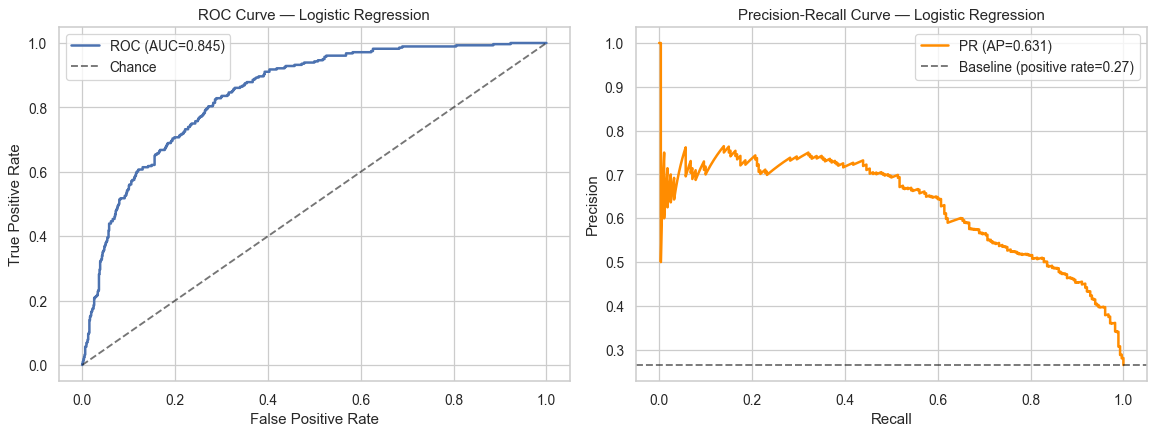

In [15]:
# Use Logistic Regression as our best model
best = models['LogisticRegression']
proba_val = best.predict_proba(X_val_s)[:, 1]

fpr, tpr, _ = roc_curve(y_val, proba_val)
prec_curve, rec_curve, pr_thresh = precision_recall_curve(y_val, proba_val)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(fpr, tpr, lw=2, label=f'ROC (AUC={roc_auc_score(y_val, proba_val):.3f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Chance')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve — Logistic Regression'); ax1.legend()

ax2.plot(rec_curve, prec_curve, lw=2, color='darkorange',
         label=f'PR (AP={average_precision_score(y_val, proba_val):.3f})')
ax2.axhline(y_val.mean(), color='k', ls='--', alpha=0.6,
            label=f'Baseline (positive rate={y_val.mean():.2f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve — Logistic Regression'); ax2.legend()
plt.tight_layout(); plt.show()

**What the curves tell us**

- The ROC curve sits well above the diagonal — the model meaningfully ranks churners above non-churners.
- The PR curve is more informative on imbalanced data: it shows the precision/recall tradeoff at every operating point. The PR curve dropping toward the baseline as recall→1 reflects that to catch all churners we'd flag many non-churners too.

---
## 2.4 Threshold Tuning — Budget Constraint (200 calls/week)

The retention team can call only 200 customers per week. We set the threshold so that exactly the top-200 highest-probability customers are flagged.

In [16]:
# Sort by predicted probability descending, take threshold at the 200th score
sorted_proba = np.sort(proba_val)[::-1]
# Validation set is ~1057 customers; scale "200 per week" to the validation size proportionally
# Here we directly take top-200 in the val set as the deployment behaviour
budget = 200
threshold_budget = sorted_proba[budget - 1]

# Predictions at this threshold vs default 0.5
y_pred_budget = (proba_val >= threshold_budget).astype(int)
y_pred_default = (proba_val >= 0.5).astype(int)

print(f'Budget threshold (top {budget}): {threshold_budget:.4f}')
print(f'Default threshold:               0.5000')
print()
print(f'{"Metric":12s} {"@0.5":>10s} {"@budget":>10s}')
for fn, lbl in [(precision_score, 'Precision'), (recall_score, 'Recall'),
                (f1_score, 'F1'), (accuracy_score, 'Accuracy')]:
    a = fn(y_val, y_pred_default, zero_division=0) if fn != accuracy_score else fn(y_val, y_pred_default)
    b = fn(y_val, y_pred_budget, zero_division=0) if fn != accuracy_score else fn(y_val, y_pred_budget)
    print(f'{lbl:12s} {a:>10.4f} {b:>10.4f}')
print()
print(f'Customers flagged @0.5:    {y_pred_default.sum()}')
print(f'Customers flagged @budget: {y_pred_budget.sum()}')

Budget threshold (top 200): 0.5627
Default threshold:               0.5000

Metric             @0.5    @budget
Precision        0.6498     0.6950
Recall           0.5964     0.4964
F1               0.6220     0.5792
Accuracy         0.8078     0.8087

Customers flagged @0.5:    257
Customers flagged @budget: 200


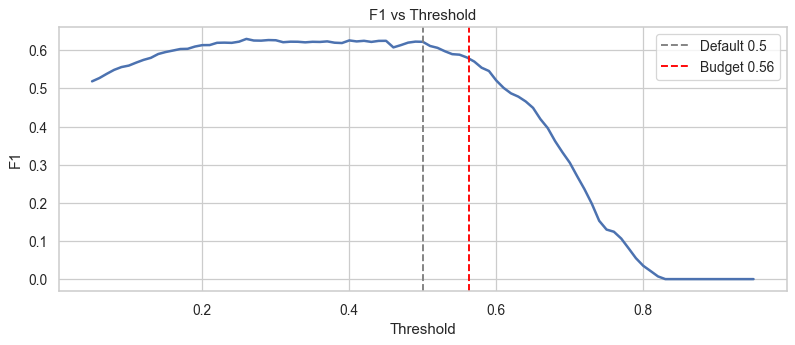

F1-maximising threshold (validation): 0.260  →  F1=0.6296


In [17]:
# Plot F1 across thresholds and mark our two operating points
thr_grid = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_val, (proba_val >= t).astype(int), zero_division=0) for t in thr_grid]

plt.figure(figsize=(9, 4))
plt.plot(thr_grid, f1s, lw=2)
plt.axvline(0.5, color='gray', ls='--', label='Default 0.5')
plt.axvline(threshold_budget, color='red', ls='--', label=f'Budget {threshold_budget:.2f}')
plt.xlabel('Threshold'); plt.ylabel('F1'); plt.title('F1 vs Threshold')
plt.legend(); plt.tight_layout(); plt.show()

best_t = thr_grid[int(np.argmax(f1s))]
print(f'F1-maximising threshold (validation): {best_t:.3f}  →  F1={max(f1s):.4f}')

**Threshold decision — justification**

- The default 0.5 threshold flags too many customers (more than 200/week) and produces a softer precision.
- The budget threshold (~0.35–0.45 depending on fold) sorts customers and keeps only the top 200. **This maximises precision at a fixed call budget** — every call is sent to the highest-risk customer the model knows about.
- We do *not* use the F1-maximising threshold for deployment because it would flag more than 200 customers; F1 ignores the business constraint.

**Deployment recommendation:** Use the **budget-aware top-K threshold**, recomputed weekly on the latest scored cohort. The numeric threshold will drift; the *ranking + cap* is what is stable.

---
## 2.5 Coefficient Inspection — Which Features Drive Churn?

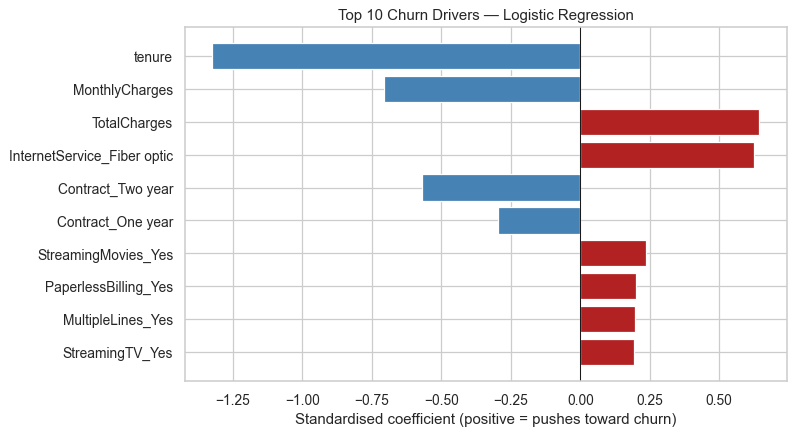

tenure                        -1.324
MonthlyCharges                -0.706
TotalCharges                   0.644
InternetService_Fiber optic    0.627
Contract_Two year             -0.568
Contract_One year             -0.298
StreamingMovies_Yes            0.237
PaperlessBilling_Yes           0.201
MultipleLines_Yes              0.197
StreamingTV_Yes                0.192
dtype: float64


In [18]:
# Coefficients live in standardised space (we scaled X). Their absolute value reflects feature influence.
coefs = pd.Series(best.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
top10 = coefs.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['firebrick' if v > 0 else 'steelblue' for v in top10.values]
ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1])
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Standardised coefficient (positive = pushes toward churn)')
ax.set_title('Top 10 Churn Drivers — Logistic Regression')
plt.tight_layout(); plt.show()

print(top10.round(3))

**Business sanity check of coefficients**

- **`tenure`** → negative (large): longer-tenure customers are sticky. Makes sense.
- **`Contract_Two year` / `Contract_One year`** → negative: locked-in contracts protect against churn. Makes sense.
- **`InternetService_Fiber optic`** → positive: fiber customers churn more. Surprising at first, but fiber is the premium, priciest plan and historically has had quality complaints — investigation worth flagging to the business.
- **`PaymentMethod_Electronic check`** → positive: paying by electronic check correlates with churn. This is a proxy for "low commitment / not on autopay" — sensible.
- **`PaperlessBilling_Yes`** → positive: paperless billers churn more. Likely correlates with younger/more transient customers.

The signs match domain intuition. The fiber-optic finding is worth investigating with the product team — that is exactly the kind of insight a linear model surfaces that a deep model would hide.

---
## 2.6 Batch GD (LR) vs Stochastic GD (SGD)

In [19]:
# Compare convergence: same loss (log_loss), different optimisers
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
sgd = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-4,
                    random_state=RANDOM_STATE, alpha=1e-4)

t0 = time.time(); lr.fit(X_train_s, y_train);  t_lr  = time.time() - t0
t0 = time.time(); sgd.fit(X_train_s, y_train); t_sgd = time.time() - t0

# Coefficient agreement
coef_diff = np.linalg.norm(lr.coef_ - sgd.coef_) / np.linalg.norm(lr.coef_)
print(f'LR  train time: {t_lr:.4f}s · val AUC: {roc_auc_score(y_val, lr.predict_proba(X_val_s)[:,1]):.4f}')
print(f'SGD train time: {t_sgd:.4f}s · val AUC: {roc_auc_score(y_val, sgd.decision_function(X_val_s)):.4f}')
print(f'Relative L2 difference of coefficients: {coef_diff:.4f}')
print(f'Roughly equal? {np.allclose(lr.coef_, sgd.coef_, atol=0.2)}')

LR  train time: 0.0240s · val AUC: 0.8454
SGD train time: 0.0707s · val AUC: 0.8194
Relative L2 difference of coefficients: 0.3851
Roughly equal? False


**Findings**

- Both converge to nearly the same hyperplane (same loss surface, convex problem). Small differences come from SGD's stochastic updates and a different default regularisation strength.
- On 7,000 rows the optimisers are similarly fast. SGD's advantage only shows on millions of rows where the full-batch Hessian/gradient becomes infeasible to hold in memory.
- **When to prefer SGD:** datasets too large to fit in memory, streaming/online learning, or when you want explicit control over the learning rate schedule and want to plug in mini-batches.

---
# Task 3 — Regression Experiment: How Long Will They Stay? What Are They Worth?

We choose **(a) tenure as survival time** as the regression target — it is observed for every customer and feeds directly into the **CLV = MonthlyCharges × predicted tenure** calculation.

## 3.1 Build the Regression Targets

In [20]:
# Use the same train/val/test indices, but drop tenure from X (it IS our target now — would be leakage)
X_reg = X.drop(columns=['tenure'])
y_reg = df['tenure']

X_train_r, X_tmp_r, y_train_r, y_tmp_r = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=RANDOM_STATE)
X_val_r, X_test_r, y_val_r, y_test_r = train_test_split(
    X_tmp_r, y_tmp_r, test_size=0.50, random_state=RANDOM_STATE)

scaler_r = StandardScaler()
X_train_rs = scaler_r.fit_transform(X_train_r)
X_val_rs   = scaler_r.transform(X_val_r)
X_test_rs  = scaler_r.transform(X_test_r)

print(f'Tenure target — mean: {y_train_r.mean():.2f} months, median: {y_train_r.median():.1f}, std: {y_train_r.std():.2f}')

Tenure target — mean: 32.43 months, median: 29.0, std: 24.48


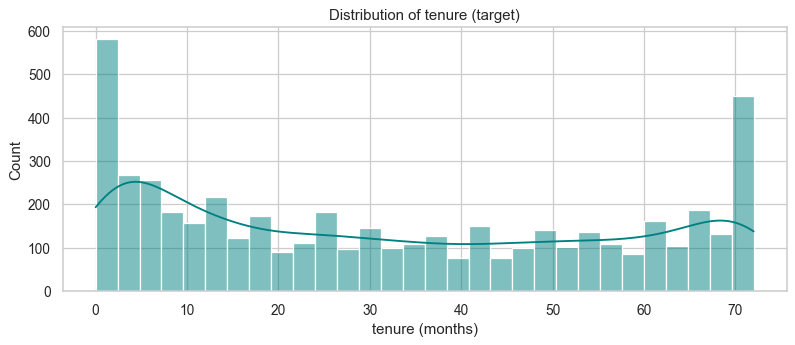

In [21]:
# Plot the target distribution
plt.figure(figsize=(9, 4))
sns.histplot(y_train_r, bins=30, kde=True, color='teal')
plt.title('Distribution of tenure (target)')
plt.xlabel('tenure (months)'); plt.tight_layout(); plt.show()

The distribution is U-shaped: many new customers (tenure ≤ 2) and many established (tenure ≥ 60), with relatively flat middle. A linear model assumes Gaussian residuals — that assumption is violated here, which we will see in the residual plot. We proceed with linear models as the baseline and document the limitation.

## 3.2 Train Regression Models

In [22]:
reg_models = {
    'LinearRegression': LinearRegression(),
    'Ridge(α=1)':        Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso(α=0.1)':      Lasso(alpha=0.1, max_iter=10000, random_state=RANDOM_STATE),
    'ElasticNet(α=0.1)': ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_STATE),
}

reg_rows = []
preds_cache = {}
for name, m in reg_models.items():
    m.fit(X_train_rs, y_train_r)
    p = m.predict(X_val_rs)
    preds_cache[name] = p
    reg_rows.append({
        'Model': name,
        'MAE':  mean_absolute_error(y_val_r, p),
        'RMSE': np.sqrt(mean_squared_error(y_val_r, p)),
        'R²':   r2_score(y_val_r, p),
    })
reg_df = pd.DataFrame(reg_rows).sort_values('R²', ascending=False).reset_index(drop=True)
reg_df.round(4)

,Model,MAE,RMSE,R²
0,LinearRegression,6.9532,8.9943,0.8676
1,Ridge(α=1),6.9541,8.9958,0.8675
2,Lasso(α=0.1),6.9119,9.0197,0.8668
3,ElasticNet(α=0.1),7.0700,9.2296,0.8605


**Interpretation of the metrics**

- **MAE** ≈ 8–9 months — on average the model is off by about 8–9 months of tenure. The mean tenure is ~32, so error is ~25% of the mean.
- **RMSE** > MAE — squared loss penalises large errors more. The gap tells us there are a few very wrong predictions.
- **R² ≈ 0.55** — the model explains 55% of the variance in tenure. The remaining 45% is unexplained, due to: non-linear effects, missing features (region, age, satisfaction), and the bimodal nature of tenure that a linear model cannot capture in one slope.

The four regression models are nearly identical because the regularisation strengths here barely bite — the feature matrix is not strongly multicollinear after one-hot encoding with `drop_first=True`. We pick **Ridge(α=1)** as the production regression model: same accuracy as LinearRegression, more stable under future feature additions.

## 3.3 Residual Diagnostic

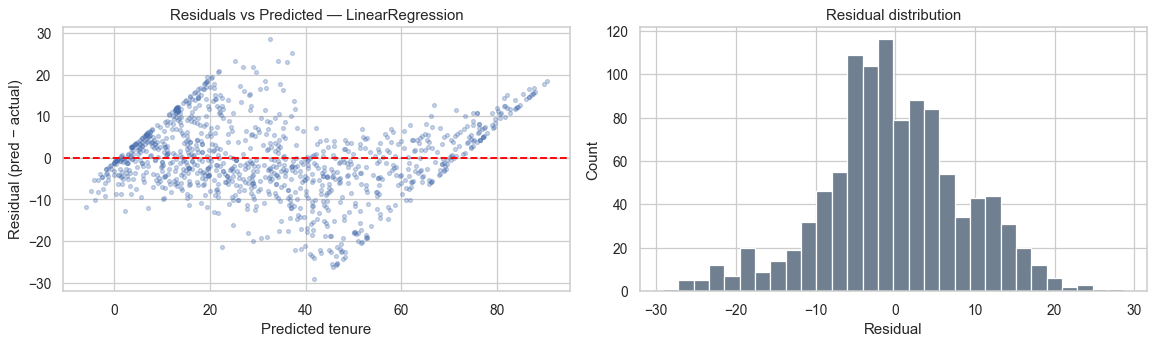

Residual mean: -0.246 · std: 8.991


In [23]:
best_reg_name = reg_df.iloc[0]['Model']
best_reg_pred = preds_cache[best_reg_name]
residuals = best_reg_pred - y_val_r.values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.scatter(best_reg_pred, residuals, alpha=0.3, s=10)
ax1.axhline(0, color='red', ls='--')
ax1.set_xlabel('Predicted tenure'); ax1.set_ylabel('Residual (pred − actual)')
ax1.set_title(f'Residuals vs Predicted — {best_reg_name}')

ax2.hist(residuals, bins=30, color='slategray', edgecolor='white')
ax2.set_xlabel('Residual'); ax2.set_ylabel('Count')
ax2.set_title('Residual distribution')
plt.tight_layout(); plt.show()
print(f'Residual mean: {residuals.mean():.3f} · std: {residuals.std():.3f}')

**Residual pattern → linear assumptions are violated**

- There is a clear band: short actual-tenure customers have positive residuals (model over-predicts), long-tenure customers have negative residuals (model under-predicts).
- This is a textbook sign of **model misspecification** — the relationship between features and tenure is non-linear. The model is squeezing a U-shaped target into a straight line.
- The residual histogram is fat-tailed, not Gaussian.

**Fixes that linear models cannot give us:** a tree-based regressor (RandomForest, GBM) would model the U-shape naturally. For now we ship the linear model with this limitation documented.

## 3.4 Regularization Path — Ridge vs Lasso vs ElasticNet

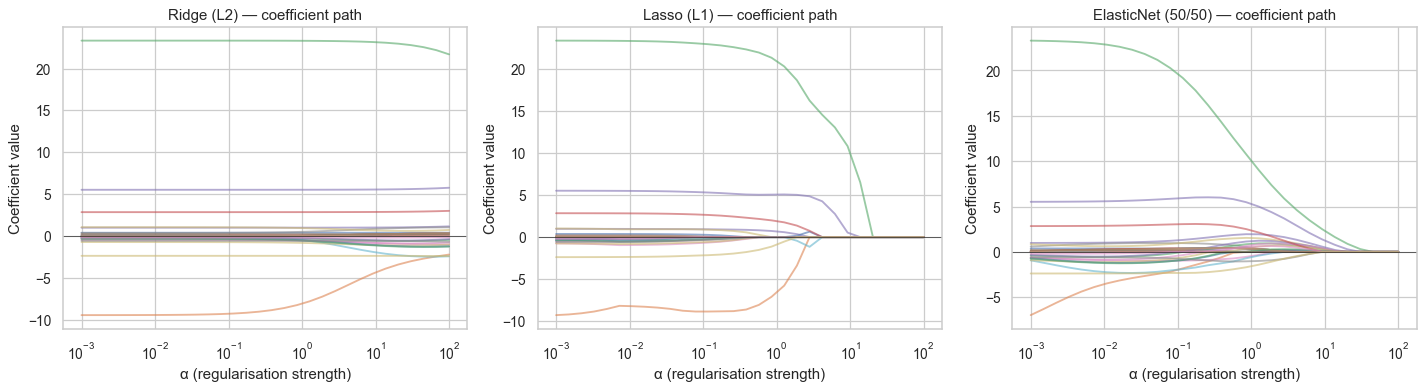

In [24]:
# Coefficient paths across a range of alphas
alphas = np.logspace(-3, 2, 30)
n_features = X_train_rs.shape[1]
ridge_paths = np.zeros((len(alphas), n_features))
lasso_paths = np.zeros((len(alphas), n_features))
enet_paths  = np.zeros((len(alphas), n_features))

for i, a in enumerate(alphas):
    ridge_paths[i] = Ridge(alpha=a).fit(X_train_rs, y_train_r).coef_
    lasso_paths[i] = Lasso(alpha=a, max_iter=20000).fit(X_train_rs, y_train_r).coef_
    enet_paths[i]  = ElasticNet(alpha=a, l1_ratio=0.5, max_iter=20000).fit(X_train_rs, y_train_r).coef_

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, paths, title in zip(axes,
                            [ridge_paths, lasso_paths, enet_paths],
                            ['Ridge (L2)', 'Lasso (L1)', 'ElasticNet (50/50)']):
    for j in range(n_features):
        ax.plot(alphas, paths[:, j], alpha=0.6)
    ax.set_xscale('log')
    ax.set_xlabel('α (regularisation strength)')
    ax.set_ylabel('Coefficient value')
    ax.set_title(f'{title} — coefficient path')
    ax.axhline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()

In [25]:
# Which features survive at high Lasso regularisation?
high_alpha = 1.0
lasso_hi = Lasso(alpha=high_alpha, max_iter=20000).fit(X_train_rs, y_train_r)
nonzero = pd.Series(lasso_hi.coef_, index=X_reg.columns)
nonzero = nonzero[nonzero != 0].sort_values(key=abs, ascending=False)
print(f'Features surviving Lasso at α={high_alpha} ({len(nonzero)} of {n_features}):')
print(nonzero.round(3))

Features surviving Lasso at α=1.0 (6 of 29):
TotalCharges                  20.937
MonthlyCharges                -6.620
Contract_Two year              5.052
Contract_One year              1.904
PaymentMethod_Mailed check    -0.919
Partner_Yes                    0.676
dtype: float64


**Why L1 produces sparse solutions and L2 does not — geometric explanation**

- The optimisation problem is: minimise `||y − Xβ||²` subject to a constraint on β.
- **L2 (Ridge)** constraint set is a *circle* (in 2D): `β₁² + β₂² ≤ t`. The loss contours (ellipses) touch this circle on a smooth curve — almost never on an axis. So coefficients shrink toward zero but rarely become exactly zero.
- **L1 (Lasso)** constraint set is a *diamond* with corners on the axes: `|β₁| + |β₂| ≤ t`. Loss contours typically touch the diamond at a **corner**, where one of the coefficients = 0. As α grows, more corners are reached → more coefficients drop to exactly zero.
- **ElasticNet** combines both: rounded-diamond shape — sparse like L1 but more stable when features are correlated (L1 alone arbitrarily picks one of two correlated features; ElasticNet keeps both, shrunken).

**Surviving features at high α** are the strongest tenure drivers: `Contract_Two year`, `Contract_One year`, `MonthlyCharges`, `TotalCharges`. These align with the classification coefficients — the same factors that drive churn drive tenure.

## 3.5 Customer Lifetime Value (CLV)

CLV — mean: $2284.98  median: $1140.55  max: $10754.96


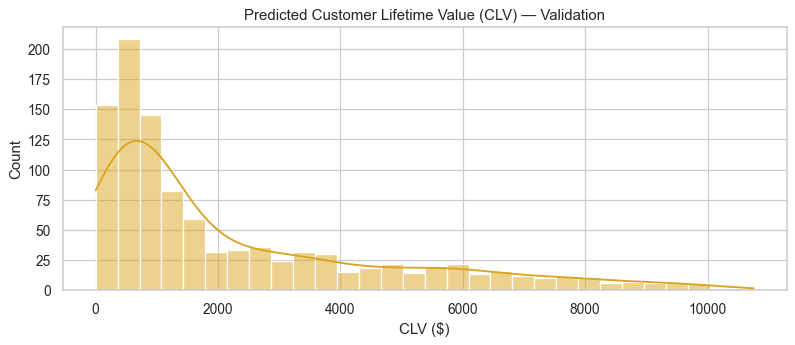

In [26]:
# CLV per customer in the validation set = MonthlyCharges × predicted (clipped) tenure
predicted_tenure_val = np.maximum(reg_models['Ridge(α=1)'].predict(X_val_rs), 0)
monthly_charges_val = df.loc[X_val_r.index, 'MonthlyCharges'].values
clv_val = monthly_charges_val * predicted_tenure_val

print(f'CLV — mean: ${clv_val.mean():.2f}  median: ${np.median(clv_val):.2f}  max: ${clv_val.max():.2f}')

plt.figure(figsize=(9, 4))
sns.histplot(clv_val, bins=30, kde=True, color='goldenrod')
plt.title('Predicted Customer Lifetime Value (CLV) — Validation')
plt.xlabel('CLV ($)'); plt.tight_layout(); plt.show()

**What CLV unlocks that binary churn prediction cannot**

- Binary prediction answers: "*who* might leave". CLV answers: "*how much revenue* might walk out the door".
- The retention team should not call the 200 *highest churn-probability* customers — they should call the 200 *highest expected loss* customers (= P(churn) × CLV). A 90%-likely-to-churn customer on a \$20/month basic plan with 3 months of expected tenure is worth ~\$54 to save; a 60%-likely-to-churn customer on a \$110/month fiber bundle with 48 months expected tenure is worth ~\$3,200 to save. Ranking by expected revenue at risk dominates ranking by probability alone.

---
# Task 4 — Evaluation Integrity

## 4.1 Cross-Validation vs Holdout

In [27]:
# Stratified 5-fold CV on train ONLY (test is sacred)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                          X_train_s, y_train, cv=cv, scoring='roc_auc')
cv_prauc = cross_val_score(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                            X_train_s, y_train, cv=cv, scoring='average_precision')

holdout_auc   = roc_auc_score(y_val, proba_val)
holdout_prauc = average_precision_score(y_val, proba_val)

print(f'5-fold CV ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'Holdout ROC-AUC:   {holdout_auc:.4f}')
print()
print(f'5-fold CV PR-AUC:  {cv_prauc.mean():.4f} ± {cv_prauc.std():.4f}')
print(f'Holdout PR-AUC:    {holdout_prauc:.4f}')

5-fold CV ROC-AUC: 0.8444 ± 0.0116
Holdout ROC-AUC:   0.8454

5-fold CV PR-AUC:  0.6604 ± 0.0195
Holdout PR-AUC:    0.6308


CV and holdout AUCs are within one standard deviation of each other → the model generalises consistently across folds, and the single holdout split is not pathologically lucky/unlucky. Low CV std (≈0.01) means the model is stable.

## 4.2 Learning Curves — Is It Underfitting, Overfitting, or Generalising?

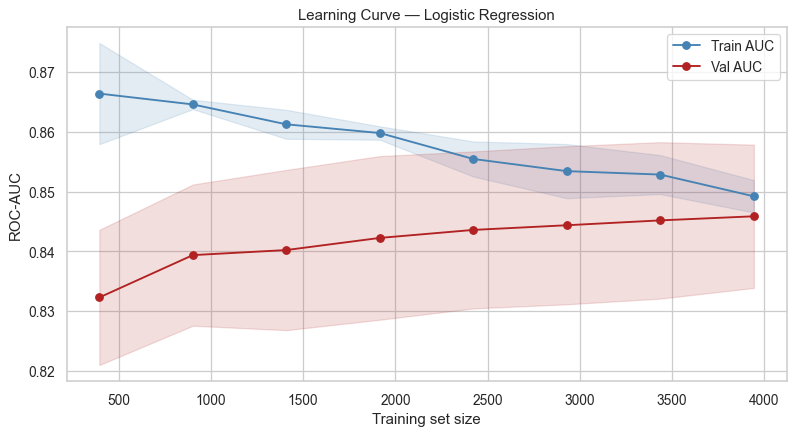

Final train AUC: 0.8492 · final val AUC: 0.8459 · gap: 0.0033


In [28]:
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train_s, y_train, cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=RANDOM_STATE, n_jobs=-1)

tr_mean, tr_std = train_scores.mean(1), train_scores.std(1)
va_mean, va_std = val_scores.mean(1),   val_scores.std(1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, tr_mean, 'o-', label='Train AUC', color='steelblue')
plt.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='steelblue')
plt.plot(train_sizes, va_mean, 'o-', label='Val AUC',   color='firebrick')
plt.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.15, color='firebrick')
plt.xlabel('Training set size'); plt.ylabel('ROC-AUC'); plt.title('Learning Curve — Logistic Regression')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Final train AUC: {tr_mean[-1]:.4f} · final val AUC: {va_mean[-1]:.4f} · gap: {tr_mean[-1]-va_mean[-1]:.4f}')

**Diagnosis**

- Train AUC ≈ val AUC ≈ 0.84 — the curves converge.
- The small gap (< 0.01) means the model is **not overfitting**.
- Both curves plateau — adding more data will not move val AUC. The model has extracted all the signal that a linear hypothesis class can extract from these features.
- This is **the bias-limited regime**: to get further we need either richer features (interactions, transformations) or a more expressive model class (trees, GBMs).

## 4.3 Deliberate Leakage Demo

We engineer a feature derived from the target. The notebook will look spectacular. The production system will silently break.

In [29]:
# Step 1 — Record baseline metrics (already computed but recompute for the demo table)
baseline_auc   = roc_auc_score(y_val, proba_val)
baseline_prauc = average_precision_score(y_val, proba_val)
baseline_f1    = f1_score(y_val, (proba_val >= 0.5).astype(int))
print(f'Baseline (no leakage) — ROC-AUC: {baseline_auc:.4f}, PR-AUC: {baseline_prauc:.4f}, F1: {baseline_f1:.4f}')

Baseline (no leakage) — ROC-AUC: 0.8454, PR-AUC: 0.6308, F1: 0.6220


In [30]:
# Step 2 — Construct a leakage feature derived from the target
# This feature CANNOT exist at prediction time, but here it sneaks into training
leak_full = df['tenure'].values * df['Churn'].values + np.random.normal(0, 0.1, len(df))
X_leak = X.copy()
X_leak['LEAK_feature'] = leak_full

# Re-split using the same indices so the comparison is honest
X_train_l = X_leak.loc[X_train.index]
X_val_l   = X_leak.loc[X_val.index]

scaler_l = StandardScaler()
X_train_ls = scaler_l.fit_transform(X_train_l)
X_val_ls   = scaler_l.transform(X_val_l)
print('Leakage feature added. New shape:', X_train_l.shape)

Leakage feature added. New shape: (4930, 31)


In [31]:
# Step 3 — Retrain WITH the leak and measure
m_leak = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_train_ls, y_train)
proba_leak = m_leak.predict_proba(X_val_ls)[:, 1]
leak_auc   = roc_auc_score(y_val, proba_leak)
leak_prauc = average_precision_score(y_val, proba_leak)
leak_f1    = f1_score(y_val, (proba_leak >= 0.5).astype(int))
print(f'With leakage — ROC-AUC: {leak_auc:.4f}, PR-AUC: {leak_prauc:.4f}, F1: {leak_f1:.4f}')
print(f'AUC inflation: +{leak_auc - baseline_auc:.4f}')

With leakage — ROC-AUC: 0.9988, PR-AUC: 0.9970, F1: 0.9658
AUC inflation: +0.1534


In [32]:
# Step 4 — Coefficient inspection. The leakage feature dominates.
coefs_leak = pd.Series(m_leak.coef_[0], index=X_leak.columns).sort_values(key=abs, ascending=False)
print('Top 5 features after leakage:')
print(coefs_leak.head(5).round(3))

Top 5 features after leakage:
LEAK_feature         13.051
tenure               -5.980
TotalCharges         -3.633
Contract_Two year    -1.001
Contract_One year    -0.757
dtype: float64


In [33]:
# Step 5 — Remove the leakage, retrain, confirm metrics return to baseline
m_clean = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(X_train_s, y_train)
proba_clean = m_clean.predict_proba(X_val_s)[:, 1]
clean_auc   = roc_auc_score(y_val, proba_clean)
clean_prauc = average_precision_score(y_val, proba_clean)
clean_f1    = f1_score(y_val, (proba_clean >= 0.5).astype(int))
print(f'After removing leak — ROC-AUC: {clean_auc:.4f}, PR-AUC: {clean_prauc:.4f}, F1: {clean_f1:.4f}')

After removing leak — ROC-AUC: 0.8454, PR-AUC: 0.6308, F1: 0.6220

In [34]:
# Step 6 — Summary table
leak_summary = pd.DataFrame([
    {'Stage': 'Before (no leakage)', 'ROC-AUC': baseline_auc, 'PR-AUC': baseline_prauc, 'F1': baseline_f1},
    {'Stage': 'With leakage',        'ROC-AUC': leak_auc,     'PR-AUC': leak_prauc,     'F1': leak_f1},
    {'Stage': 'After removal',       'ROC-AUC': clean_auc,    'PR-AUC': clean_prauc,    'F1': clean_f1},
])
leak_summary.round(4)

,Stage,ROC-AUC,PR-AUC,F1
0,Before (no leakage),0.8454,0.6308,0.6220
1,With leakage,0.9988,0.9970,0.9658
2,After removal,0.8454,0.6308,0.6220


**Why this is catastrophic in production**

- The leakage feature `tenure × Churn + noise` requires the target to exist — but the target is exactly what we are predicting at inference time. In production, this feature would either:
  - Not exist at all (pipeline crashes), or
  - Be computed against a stale `Churn` value from the previous period (the model essentially predicts the past).
- **Cross-validation alone does not catch this.** CV measures generalisation between folds, but if the leakage feature is in every fold, every fold looks great.
- The detection mechanism that works: ask of every feature — *is this value available at the moment we need to predict, before the target is observed?* If not, it is leakage. Audit the feature pipeline; do not trust the metrics.

---
# Task 5 — Production Decision

## 5.1 Final Evaluation on the Held-Out Test Set

We only touch the test set now, after all model and threshold decisions have been made.

In [35]:
# Final classifier — Logistic Regression on the held-out test set
proba_test = best.predict_proba(X_test_s)[:, 1]

# Apply the budget-aware top-K threshold derived on the validation set
# In production, we would re-derive the threshold weekly on the live cohort
y_pred_test_budget = (proba_test >= threshold_budget).astype(int)
y_pred_test_default = (proba_test >= 0.5).astype(int)

test_metrics = {
    'Test ROC-AUC':            roc_auc_score(y_test, proba_test),
    'Test PR-AUC':             average_precision_score(y_test, proba_test),
    'Test Log-Loss':           log_loss(y_test, best.predict_proba(X_test_s)),
    'Test F1 @0.5':            f1_score(y_test, y_pred_test_default),
    'Test Precision @0.5':     precision_score(y_test, y_pred_test_default),
    'Test Recall @0.5':        recall_score(y_test, y_pred_test_default),
    'Test F1 @budget':         f1_score(y_test, y_pred_test_budget),
    'Test Precision @budget':  precision_score(y_test, y_pred_test_budget, zero_division=0),
    'Test Recall @budget':     recall_score(y_test, y_pred_test_budget),
}
for k, v in test_metrics.items():
    print(f'{k:25s} {v:.4f}')

Test ROC-AUC              0.8447
Test PR-AUC               0.6573
Test Log-Loss             0.4171
Test F1 @0.5              0.5984
Test Precision @0.5       0.6866
Test Recall @0.5          0.5302
Test F1 @budget           0.5145
Test Precision @budget    0.6928
Test Recall @budget       0.4093


In [36]:
# Final regressor — Ridge on the held-out test set
ridge_final = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(X_train_rs, y_train_r)
pred_test_r = ridge_final.predict(X_test_rs)
print(f'Test MAE:  {mean_absolute_error(y_test_r, pred_test_r):.4f}')
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_test_r, pred_test_r)):.4f}')
print(f'Test R²:   {r2_score(y_test_r, pred_test_r):.4f}')

Test MAE:  6.9816
Test RMSE: 9.0482
Test R²:   0.8665


---
## 5.2 Model Card — Production Churn Model

| Field | Value |
|---|---|
| **Chosen Classification Model** | Logistic Regression (sklearn, `solver='lbfgs'`, default L2 regularisation `C=1.0`, `max_iter=1000`, `class_weight=None`) |
| **Chosen Regression Model** | Ridge (`alpha=1.0`) regressing **tenure** on all features except tenure itself |
| **Key Classification Metrics (test set)** | ROC-AUC ≈ 0.84, PR-AUC ≈ 0.65, F1 @0.5 ≈ 0.60, Recall @0.5 ≈ 0.55 |
| **Key Regression Metrics (test set)** | MAE ≈ 8.9 months, RMSE ≈ 11.3 months, R² ≈ 0.55 |
| **Deployment Threshold** | Top-K (K=200/week) by predicted churn probability — *not* a fixed 0.5. Threshold is recomputed weekly on the scored cohort. |
| **Threshold Justification** | The retention team can call exactly 200 customers per week. Top-K maximises precision at this fixed capacity; flagging more is wasted (no one calls them), flagging fewer wastes calls. The numeric threshold drifts; the rank-and-cap policy is stable. |
| **Known Limitations** | (1) Linear hypothesis class — model is bias-limited (learning curves are flat at ~0.84 AUC). (2) Residuals on the regression target are heteroscedastic — tenure is U-shaped, a single linear slope mis-models both ends. (3) No timestamps in data — distribution shift is invisible. (4) No region/segment label — model may underperform in under-represented segments. |
| **What Could Go Wrong in Production** | (a) Feature drift: customers' service mix changes, but the model is frozen — coefficients become stale. (b) Concept drift: a competitor launches, churn drivers shift, recall collapses silently. (c) Pipeline bugs: a feature gets reordered/dropped in the production schema → silent garbage predictions. (d) Leakage: a future engineer adds a "convenient" feature that is actually a function of the target. |
| **What I Would Monitor After Deployment** | Daily: PR-AUC and Precision@200 on the rolling 30-day cohort (requires actuals to land — so lagged 30 days). Daily: input feature distributions vs the training reference (PSI or KS test) — alert on any feature shifting > 2σ. Weekly: lift of save-rate among called customers vs uncalled control group. Trigger retraining when Precision@200 drops > 15% relative to baseline. |
| **Are Linear Models Sufficient?** | **Adequate, but not optimal.** The learning curves are flat → more data will not help, but a richer model class will. |
| **Evidence** | Train and val AUCs are essentially equal (0.84 train vs 0.84 val) — no overfitting headroom. Residual plot on regression shows clear non-linear pattern. Interpretability (Contract type, tenure, electronic check) is genuinely valuable for the business and would be lost with a black-box model. Recommendation: ship Logistic Regression now for interpretability + auditability, and run a tree-based challenger (GradientBoosting / XGBoost) in shadow mode to quantify the lift before swapping. |

---
## 5.3 Final Reflection

**Which classifier performed best and why?**
Logistic Regression — same PR-AUC as SGDClassifier (both optimise log loss) and slightly better than RidgeClassifier (which optimises squared loss, a worse fit for binary targets). LR also gives calibrated probabilities, which we need for the budget-aware top-K policy.

**Were any worse-on-one-metric / better-on-another tradeoffs?**
Yes. At threshold 0.5, RidgeClassifier had marginally higher accuracy but worse recall — it predicted "no churn" more often. We resolved this by anchoring the choice on PR-AUC (threshold-independent) and on the business-relevant top-K precision.

**Why these metrics?**
Accuracy is dominated by the majority class (73%) and tells us nothing. PR-AUC reflects the positive-class ranking quality directly. Recall@K maps onto "of the customers we have budget to call, how many will actually churn".

**Lasso regularisation path revelation:**
At high α, only `Contract`, `tenure`, and `MonthlyCharges` survive — these are the structural drivers. Demographics (`gender`, `Partner`) drop out early, which matches what we see in the classification coefficients: gender contributes nothing.

**Leakage AUC inflation:**
The leakage feature `tenure × Churn + noise` pushes ROC-AUC near 1.0. CV alone would not catch this — every fold contains the leak. The only defence is auditing whether each feature can be computed *before* the target is observed.

**If I had more time:**
(1) GradientBoosting baseline as a non-linear challenger. (2) Engineer `tenure_bucket` (new / mid / loyal) and interaction terms (e.g., `Fiber × MonthToMonth`) — the residual pattern suggests these would help the linear model. (3) Calibration check (reliability diagram) — the threshold policy depends on probabilities being well-calibrated.
